# Temporal-Only Baseline Models

Progressive models from temporal features only to temporal + pollution history.

In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Load Data

In [22]:
DATA_PATH = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Dataset shape: (9457112, 39)
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00


In [23]:
coverage_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': lambda x: x.notna().mean(),
    'timestamp': ['min', 'max']
})
coverage_stats.columns = ['coverage_ratio', 'start_date', 'end_date']
coverage_stats['duration_days'] = (coverage_stats['end_date'] - coverage_stats['start_date']).dt.days

high_coverage_hexagons = coverage_stats[
    (coverage_stats['coverage_ratio'] >= 0.90) & 
    (coverage_stats['duration_days'] >= 100)
].index.tolist()

df = df[df['hex7_id'].isin(high_coverage_hexagons)].copy()
print(f"Selected {len(high_coverage_hexagons)} high coverage hexagons")
print(f"Filtered dataset: {df.shape}")

Selected 485 high coverage hexagons
Filtered dataset: (7320911, 39)


In [24]:
pm25_cap = df['pm25_ugm3_mean'].quantile(0.999)
df['pm25_ugm3_mean'] = df['pm25_ugm3_mean'].clip(upper=pm25_cap)

df['pm25'] = df.groupby('hex7_id')['pm25_ugm3_mean'].transform(
    lambda x: x.interpolate(method='linear', limit=3)
)

df = df.dropna(subset=['pm25'])
print(f"Final dataset: {df.shape}")

Final dataset: (7241466, 40)


## Create Temporal Features

In [25]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['hour'] = df['timestamp'].dt.hour

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [26]:
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

df['pm25_24h_ago'] = df.groupby('hex7_id')['pm25'].shift(24)
df['pm25_12h_ago'] = df.groupby('hex7_id')['pm25'].shift(12)
df['pm25_48h_ago'] = df.groupby('hex7_id')['pm25'].shift(48)
df['pm25_168h_ago'] = df.groupby('hex7_id')['pm25'].shift(168)

In [27]:
horizons = [1, 2, 3, 4, 5, 6, 12, 24]
target_cols = []

for h in horizons:
    col_name = f'target_{h}h'
    df[col_name] = df.groupby('hex7_id')['pm25'].shift(-h)
    target_cols.append(col_name)

## Define Feature Sets

In [28]:
features_A = ['year', 'month', 'day_of_week', 'hour',
              'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

features_B = features_A + ['pm25_24h_ago']

features_C = features_B + ['pm25_12h_ago', 'pm25_48h_ago', 'pm25_168h_ago']

print(f"Model A features: {len(features_A)}")
print(f"Model B features: {len(features_B)}")
print(f"Model C features: {len(features_C)}")

Model A features: 10
Model B features: 11
Model C features: 14


## Train/Test Split

In [29]:
df = df.dropna(subset=features_C + target_cols)

train_data = df[df['year'].isin([2023, 2024])].copy()
test_data = df[df['year'] == 2025].copy()

print(f"Train: {len(train_data):,} samples")
print(f"Test: {len(test_data):,} samples")

Train: 5,080,144 samples
Test: 2,068,202 samples


# Train Models

In [30]:
def train_and_evaluate(train_data, test_data, features, model_name):
    results = {}
    scaler = StandardScaler()
    
    X_train = scaler.fit_transform(train_data[features])
    X_test = scaler.transform(test_data[features])
    
    for target_col in target_cols:
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)
        
        horizon = target_col.split('_')[1]
        results[horizon] = {'mae': mae, 'r2': r2, 'predictions': predictions}
    
    return results

In [31]:
print("Training models...")
results_A = train_and_evaluate(train_data, test_data, features_A, 'Model A')
print("Model A complete")
results_B = train_and_evaluate(train_data, test_data, features_B, 'Model B')
print("Model B complete")
results_C = train_and_evaluate(train_data, test_data, features_C, 'Model C')
print("Model C complete - all training finished")

Training models...
Model A complete
Model B complete
Model C complete - all training finished


## Results Comparison

In [32]:
horizon_list = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']

mae_comparison = pd.DataFrame(index=['Model_A', 'Model_B', 'Model_C'], columns=horizon_list)
r2_comparison = pd.DataFrame(index=['Model_A', 'Model_B', 'Model_C'], columns=horizon_list)

for horizon in horizon_list:
    mae_comparison.loc['Model_A', horizon] = results_A[horizon]['mae']
    mae_comparison.loc['Model_B', horizon] = results_B[horizon]['mae']
    mae_comparison.loc['Model_C', horizon] = results_C[horizon]['mae']
    
    r2_comparison.loc['Model_A', horizon] = results_A[horizon]['r2']
    r2_comparison.loc['Model_B', horizon] = results_B[horizon]['r2']
    r2_comparison.loc['Model_C', horizon] = results_C[horizon]['r2']

print("MAE Comparison (μg/m³):")
print(mae_comparison.round(2))
print("\nR² Score Comparison:")
print(r2_comparison.round(3))

MAE Comparison (μg/m³):
           1h    2h    3h    4h    5h    6h   12h   24h
Model_A 5.304 5.304 5.304 5.305 5.305 5.305 5.307 5.313
Model_B 4.865 4.907 4.945 4.977 5.004 5.027 5.116 5.206
Model_C 4.364 4.427 4.482 4.530 4.572 4.608 4.818 5.126

R² Score Comparison:
            1h     2h     3h     4h     5h     6h    12h    24h
Model_A -0.046 -0.046 -0.046 -0.047 -0.047 -0.047 -0.047 -0.047
Model_B  0.169  0.153  0.139  0.126  0.115  0.105  0.067  0.031
Model_C  0.343  0.324  0.307  0.292  0.280  0.269  0.198  0.083


In [33]:
improvement_B_over_A = pd.DataFrame(index=['MAE_reduction', 'R2_increase'], columns=horizon_list)
improvement_C_over_B = pd.DataFrame(index=['MAE_reduction', 'R2_increase'], columns=horizon_list)

for horizon in horizon_list:
    mae_A = results_A[horizon]['mae']
    mae_B = results_B[horizon]['mae']
    mae_C = results_C[horizon]['mae']
    
    r2_A = results_A[horizon]['r2']
    r2_B = results_B[horizon]['r2']
    r2_C = results_C[horizon]['r2']
    
    improvement_B_over_A.loc['MAE_reduction', horizon] = mae_A - mae_B
    improvement_B_over_A.loc['R2_increase', horizon] = r2_B - r2_A
    
    improvement_C_over_B.loc['MAE_reduction', horizon] = mae_B - mae_C
    improvement_C_over_B.loc['R2_increase', horizon] = r2_C - r2_B

print("\nImprovement B over A (adding 24h lag):")
print(improvement_B_over_A.round(3))
print("\nImprovement C over B (adding more lags):")
print(improvement_C_over_B.round(3))


Improvement B over A (adding 24h lag):
                 1h    2h    3h    4h    5h    6h   12h   24h
MAE_reduction 0.439 0.396 0.359 0.328 0.300 0.278 0.190 0.108
R2_increase   0.215 0.199 0.185 0.173 0.162 0.152 0.114 0.078

Improvement C over B (adding more lags):
                 1h    2h    3h    4h    5h    6h   12h   24h
MAE_reduction 0.500 0.480 0.463 0.447 0.432 0.420 0.298 0.080
R2_increase   0.174 0.171 0.168 0.166 0.165 0.164 0.131 0.053


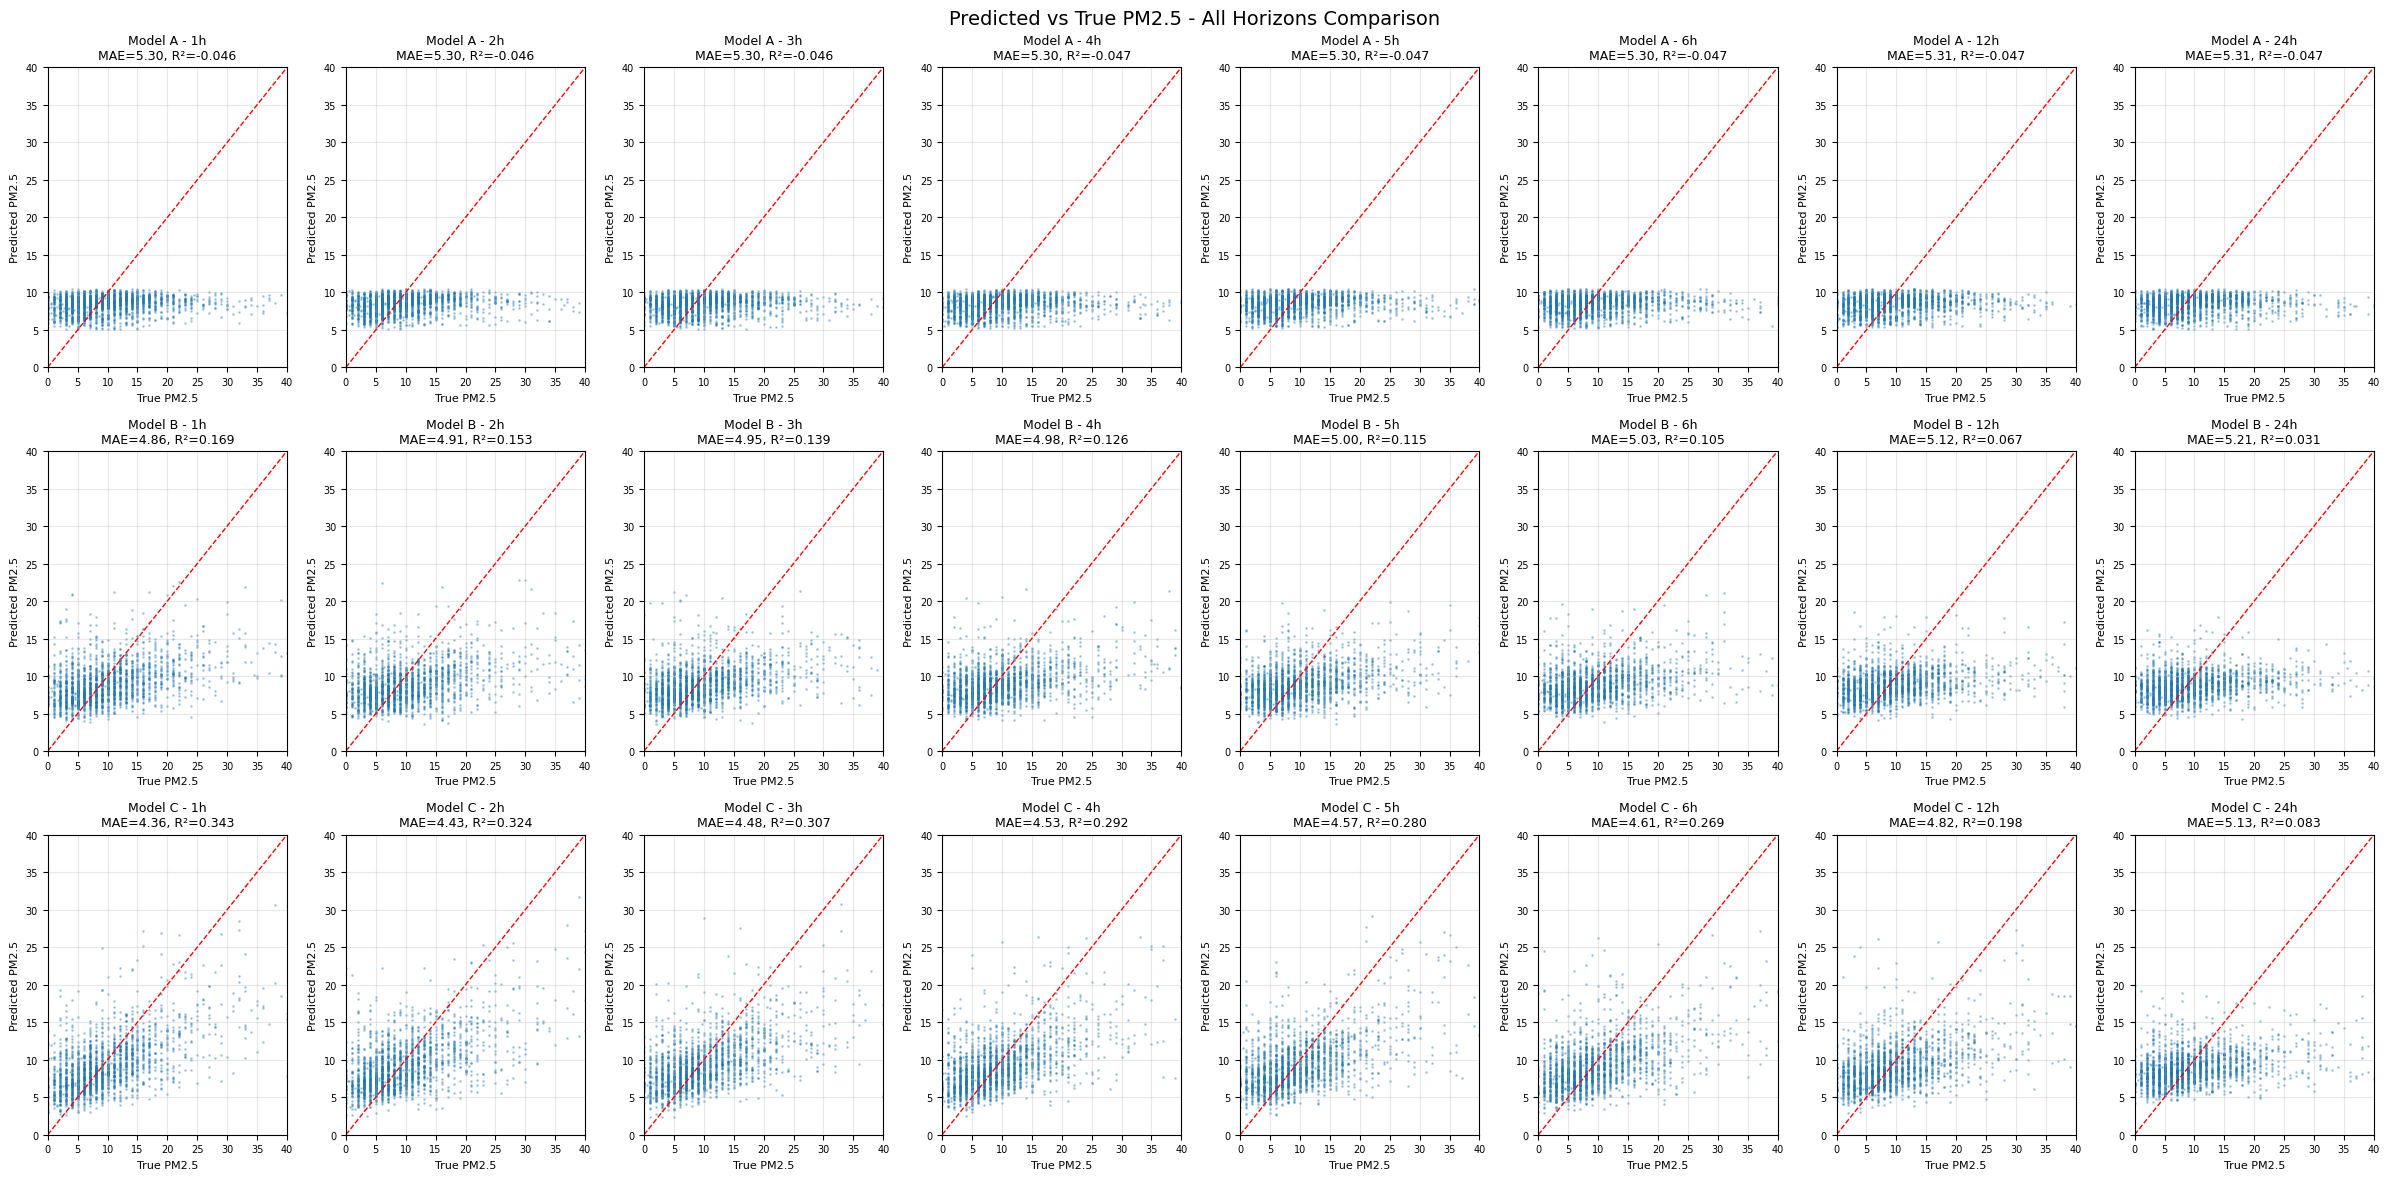

In [34]:
fig, axes = plt.subplots(3, 8, figsize=(24, 12))

models = [('Model A', results_A), ('Model B', results_B), ('Model C', results_C)]

for row_idx, (model_name, results) in enumerate(models):
    for col_idx, horizon in enumerate(horizon_list):
        ax = axes[row_idx, col_idx]
        
        y_true = test_data[f'target_{horizon}']
        y_pred = results[horizon]['predictions']
        
        sample_size = min(2000, len(y_true))
        sample_idx = np.random.choice(len(y_true), sample_size, replace=False)
        
        ax.scatter(y_true.iloc[sample_idx], y_pred[sample_idx], alpha=0.3, s=1)
        ax.plot([0, 50], [0, 50], 'r--', lw=1)
        
        mae = results[horizon]['mae']
        r2 = results[horizon]['r2']
        
        ax.set_title(f'{model_name} - {horizon}\nMAE={mae:.2f}, R²={r2:.3f}', fontsize=9)
        ax.set_xlabel('True PM2.5', fontsize=8)
        ax.set_ylabel('Predicted PM2.5', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 40)
        ax.tick_params(labelsize=7)

plt.suptitle('Predicted vs True PM2.5 - All Horizons Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Visualizations

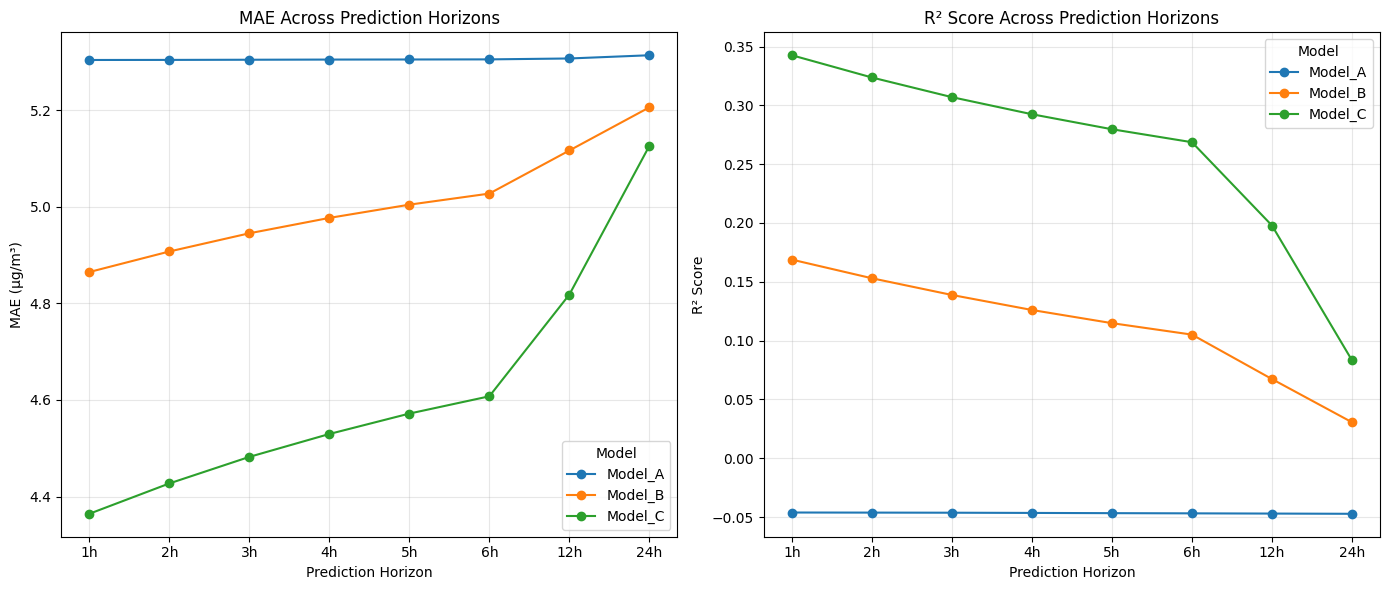

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mae_comparison.T.plot(kind='line', ax=axes[0], marker='o')
axes[0].set_title('MAE Across Prediction Horizons')
axes[0].set_xlabel('Prediction Horizon')
axes[0].set_ylabel('MAE (μg/m³)')
axes[0].legend(title='Model')
axes[0].grid(True, alpha=0.3)

r2_comparison.T.plot(kind='line', ax=axes[1], marker='o')
axes[1].set_title('R² Score Across Prediction Horizons')
axes[1].set_xlabel('Prediction Horizon')
axes[1].set_ylabel('R² Score')
axes[1].legend(title='Model')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()